In [ ]:
import polars as pl
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import math
import itertools
from procompa import get_project_root, get_data_dir

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"
data_dir_YM = get_data_dir() / "26.04_yeast.MAP"

In [2]:
import polars as pl
from procompa import get_project_root, get_data_dir

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"
Complex = pl.read_csv (data_dir / "Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv", separator="\t")


In [14]:
Complex = Complex.with_columns(
    pl.col("Identifiers (and stoichiometry) of molecules in complex")
    .str.split("|")
    .list.eval(
        pl.element().str.replace(r"\(\d+\)", "")
    )
    .alias("Identifiers_clean")
)

In [15]:
unique_ids = (
    Complex
    .select(pl.col("Identifiers_clean").list.explode())
    .unique()
    .to_series()
    .to_list()
)

In [16]:
len(unique_ids)

2003

for whcih complexes does Ym add sth? (check that i kept highest jacard index), does that make senese- function and iptm score? also what is the prop score between the added proteins

In [3]:
Ym_compl_overlap = pl.read_csv( data_dir/ "Complex_Portal/YeastMap/complex_db_complete_unique_overlap_complex_yeastmap_by_complex.csv")

In [4]:
additional_prot = Ym_compl_overlap.filter(pl.col("size_pred")>pl.col("size_true")).with_columns(
    size_diff = pl.col("size_pred") - pl.col("size_true")
) 


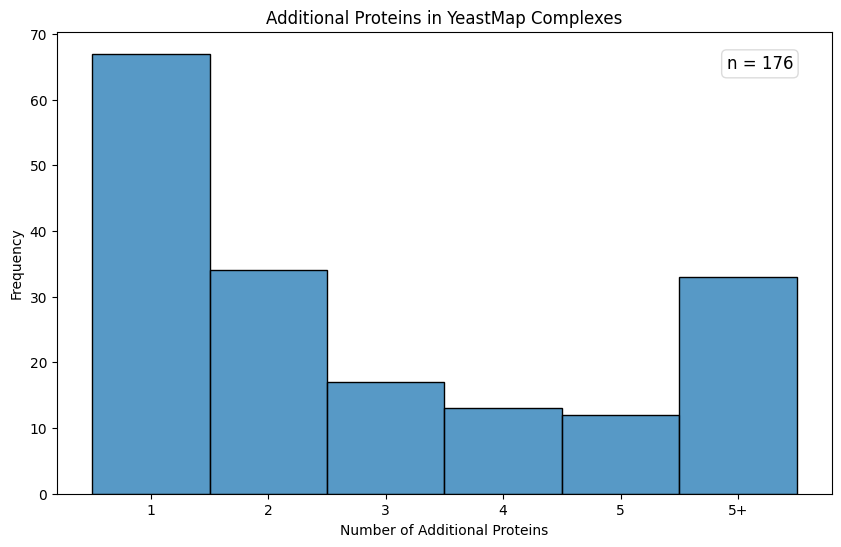

In [13]:
# 1. Cap data and calculate the total number of complexes (n)
plot_data = additional_prot["size_diff"].clip(upper_bound=6)
n_complexes = len(additional_prot)  # Gets total row count

plt.figure(figsize=(10, 6))

# Capture the axes object (ax) from the histplot
ax = sns.histplot(plot_data, discrete=True)

plt.title("Additional Proteins in YeastMap Complexes")
plt.xlabel("Number of Additional Proteins")
plt.ylabel("Frequency")
plt.xticks(ticks=range(1, 7), labels=['1', '2', '3', '4', '5', '5+'])


ax.text(
    x=0.95, 
    y=0.95, 
    s=f"n = {n_complexes:,}",  # Formats with commas if n is large
    transform=ax.transAxes, 
    horizontalalignment='right', 
    verticalalignment='top',
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgray", alpha=0.8)
)

plt.show()

In [5]:
#core proteins:proteins in pred and true complex, additonal proteins:proteins in pred but not in true complex
additional_prot = additional_prot.with_columns([
    (
        pl.col("predicted_complex").str.split(" ")
        .list.set_difference(pl.col("true_complex").str.split(" "))
        .list.join(" ")
        .alias("additional_proteins")
    ),
    (
        pl.col("predicted_complex").str.split(" ")
        .list.set_intersection(pl.col("true_complex").str.split(" "))
        .list.join(" ")
        .alias("core_proteins")
    )
])

In [6]:
def make_pairs(proteins: list[str]) -> list[str]:
    proteins = sorted(proteins)
    return [f"{proteins[i]}-{proteins[j]}" for i in range(len(proteins)) for j in range(i+1, len(proteins))]

def explode_pairs(df: pl.DataFrame) -> pl.DataFrame:
    df = df.with_columns(
        pl.col("predicted_complex").str.split(" ").alias("proteins")
    ).with_columns(
        pl.col("proteins").map_elements(make_pairs, return_dtype=pl.List(pl.String)).alias("pair")
    ).explode("pair").with_columns([
        pl.col("pair").str.split_exact("-", 1).struct.field("field_0").alias("protein_A"),
        pl.col("pair").str.split_exact("-", 1).struct.field("field_1").alias("protein_B"),
    ]).drop("pair", "proteins")

    cols = df.columns
    base = [c for c in cols if c not in ("protein_A", "protein_B")]
    idx = base.index("true_complex") + 1
    return df.select(base[:idx] + ["protein_A", "protein_B"] + base[idx:])

In [11]:
# Read the iptm parquet
iptm = pl.read_parquet(data_dir/ "iPTM/yeast_pairs_iptm_mapped.parquet")

# Normalize pair ordering in both DataFrames (p1 <= p2) for consistent joins
def join_iptm(pairs_df: pl.DataFrame, iptm_df: pl.DataFrame) -> pl.DataFrame:
    # Normalize iptm pairs
    iptm_norm = iptm_df.with_columns([
        pl.min_horizontal("protein_A", "protein_B").alias("p1"),
        pl.max_horizontal("protein_A", "protein_B").alias("p2"),
    ])

    # Normalize your pairs
    pairs_norm = pairs_df.with_columns([
        pl.min_horizontal("protein_A", "protein_B").alias("p1"),
        pl.max_horizontal("protein_A", "protein_B").alias("p2"),
    ])

    # Left join — keep all your pairs, attach iptm where available
    result = pairs_norm.join(iptm_norm, on=["p1", "p2"], how="left").drop("p1", "p2")

    # Remove duplicate columns from the iptm side (protein_A_right, protein_B_right)
    result = result.drop([c for c in result.columns if c.endswith("_right")])

    return result

additional_prot_with_iptm = join_iptm(additional_prot_pairs, iptm)

In [ ]:
additional_prot_with_iptm_with_homodimer_pdb = additional_prot_with_iptm.filter(pl.col("chain_pair_iptm_best").is_not_null())


In [ ]:
core_set = set(additional_prot_with_iptm_with_homodimer_pdb["core_proteins"].str.split(" ").explode().unique().to_list())
additional_prot_with_iptm_with_homodimer_pdb["predicted_complex"].str.split(" ").explode().unique().to_list()

additional_prot_with_iptm_with_homodimer_pdb = additional_prot_with_iptm_with_homodimer_pdb.with_columns(
    (
        (pl.col("protein_A").is_in(core_set) & ~pl.col("protein_B").is_in(core_set)) |
        (~pl.col("protein_A").is_in(core_set) & pl.col("protein_B").is_in(core_set))
    ).alias("added_yeast_prot")
)

In [15]:
max_added = (
    additional_prot_with_iptm_with_homodimer_pdb.filter(pl.col("added_yeast_prot"))
    .group_by("predicted_complex")
    .agg(pl.col("chain_pair_iptm_mean_corrected").max().alias("max_iptm_added_yeast"))
)

additional_prot_with_iptm_with_homodimer_pdb = additional_prot_with_iptm_with_homodimer_pdb.join(max_added, on="predicted_complex", how="left")

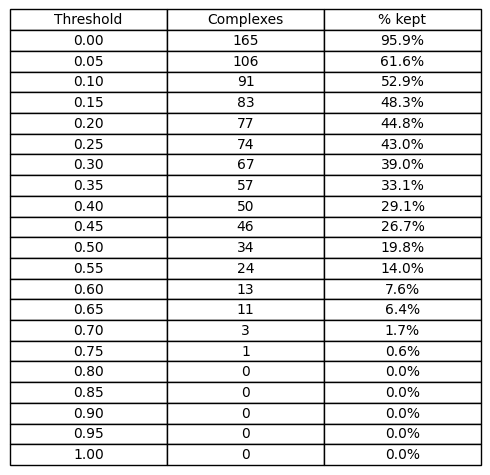

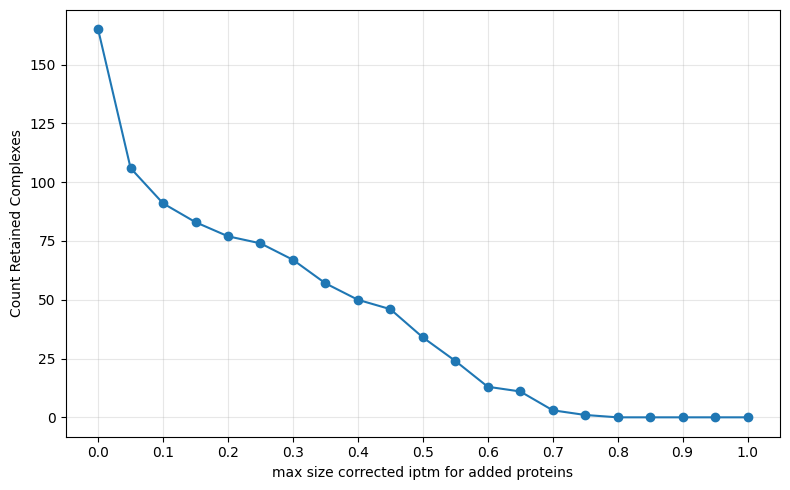

In [ ]:
n_total = additional_prot_with_iptm_with_homodimer_pdb["predicted_complex"].n_unique()
thresholds = np.arange(0.0, 1.01, 0.05)

# Table
rows = []
for t in thresholds:
    n = additional_prot_with_iptm_with_homodimer_pdb.filter(pl.col("max_iptm_added_yeast") >= t)["predicted_complex"].n_unique()
    rows.append([f"{t:.2f}", str(n), f"{100*n/n_total:.1f}%"])

fig, ax = plt.subplots(figsize=(5, 5))
ax.axis("off")
table = ax.table(cellText=rows, colLabels=["Threshold", "Complexes", "% kept"], loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.4)

plt.tight_layout()
plt.show()

# Lineplot
n_kept = [int(r[1]) for r in rows]
plt.figure(figsize=(8, 5))
plt.plot(thresholds, n_kept, marker="o", color="tab:blue")
plt.xlabel("max size corrected iptm for added proteins")
plt.ylabel("Count Retained Complexes")
#plt.title("Complexes retained vs max iptm of added yeast protein")
plt.xticks(np.arange(0, 1.01, 0.1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

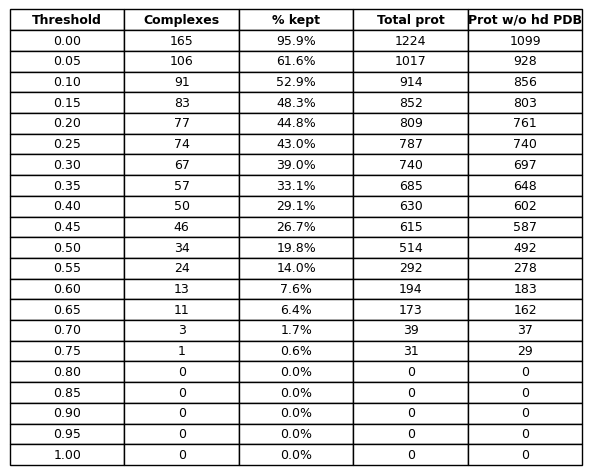

In [ ]:
homodimer_pdb = pl.read_csv(data_dir/ "Pipeline/homodimer_pdb_files/merged_pdbs/pdb_file_names.csv")
#homodimer_pdb["uniprot_id_homodimer"]


n_total = additional_prot_with_iptm_with_homodimer_pdb["predicted_complex"].n_unique()
homodimer_set = set(homodimer_pdb["uniprot_id_homodimer"].to_list())
thresholds = np.arange(0.0, 1.01, 0.05)

rows = []
for t in thresholds:
    kept = additional_prot_with_iptm_with_homodimer_pdb.filter(pl.col("max_iptm_added_yeast") >= t)
    n = kept["predicted_complex"].n_unique()
    kept_proteins = set(kept["predicted_complex"].str.split(" ").explode().unique().to_list())
    n_total_prot = len(kept_proteins)
    n_no_homodimer = len(kept_proteins - homodimer_set)
    rows.append([f"{t:.2f}", str(n), f"{100*n/n_total:.1f}%", str(n_total_prot), str(n_no_homodimer)])

fig, ax = plt.subplots(figsize=(6, 5))
ax.axis("off")
table = ax.table(cellText=rows, colLabels=["Threshold", "Complexes", "% kept", "Total prot", "Prot w/o hd PDB"], loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.4)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_text_props(fontweight="bold")
plt.tight_layout()
plt.show()

# Completely new predicitons

In [3]:
#ccompletely new predictions
new_ym_predictions = Ym_compl_overlap.filter(pl.col("match_count") == 0)

## Complexes i would be intrested in

At least trimers
strcuture unknown (also in a different species/ conserved)
chekc that i cover iptm range
then get the homodimer files